## 1. Import Required Libraries

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Import cosmocore modules
from cosmocore import (
    InputParams,
    compute_signal_matrix,
    read_maps,
)
from cosmocore._mpi import MPI

# Import qube modules
from picslike import PICSLike

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

All imports successful!
MPI size: 1, rank: 0


In [2]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [3]:
PICSLIKE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))


def resolve_config(config_rel, overrides=None):
    """Anchor YAML paths to picslike root so the notebook runs from any cwd."""
    full_path = os.path.join(PICSLIKE_ROOT, config_rel)
    with open(full_path) as f:
        config = yaml.safe_load(f)
    for key, value in config.items():
        if isinstance(value, str):
            clean = value
            while clean.startswith("../"):
                clean = clean[3:]
            if clean.startswith("tests/") or clean.startswith("scripts/"):
                config[key] = os.path.join(PICSLIKE_ROOT, clean)
    if overrides:
        config.update(overrides)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".yaml", delete=False)
    yaml.dump(config, tmp, default_flow_style=False)
    tmp.close()
    return tmp.name

In [4]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "B"  # Use TQU configuration for debugging
nside = 8
# The fixture YAML defines only 3 r values, which is too sparse to see
# a likelihood peak. The theory_spectra/ directory ships 419 precomputed
# spectra across r in [0, 0.005] in 1.25e-5 increments, so we override
# the grid here to a denser linspace that hits exact filenames.
param_file = resolve_config(
    f"tests/data/nside{nside}/{fields}/fortran_reference/config.yaml",
    overrides={"parameters": {"r": [0.0, 0.005, 41]}},
)

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"physical_labels: {getattr(params, 'physical_labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.picslike/notebooks
Parameter file: /tmp/tmpvnnsjxrf.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 8
spins: [0]
labels: ['B']
physical_labels: ['B']
nspectra: 1
lmax: 16
nsims: 1
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [5]:
# Initialize Spectra instance
print("Creating Spectra instance...")
likelihood = PICSLike(param_file)

# Display MPI and basic info
print(f"MPI rank: {likelihood.rank}")
print(f"MPI size: {likelihood.size}")
print(f"Parameters loaded: {likelihood.params is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {likelihood.maps1}")

Creating Spectra instance...
2026-05-15 15:20:15 | picslike     | INFO     | PICSLike initialized!


MPI rank: 0
MPI size: 1
Parameters loaded: True

=== Initial Variable States ===
maps1: None


## 4. Setup Fields and Geometry

In [6]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
likelihood.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
likelihood.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"nside: {params.nside}")
print(f"Total pixels: {params.nside**2 * 12}")
print(f"npixs type: {type(likelihood.npixs)}")
print(f"npixs: {likelihood.npixs}")
print(f"n_active: {likelihood.collection.n_active}")
print(f"Total pixels: {sum(likelihood.collection.n_active)}")

if hasattr(likelihood, "pixact") and likelihood.pixact is not None:
    print(f"pixact type: {type(likelihood.pixact)}")
    print(f"pixact length: {len(likelihood.pixact)}")
    for i, pix in enumerate(likelihood.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(likelihood, "collection") and likelihood.collection is not None:
    print(f"\nSpectra labels: {likelihood.collection.spectra_labels}")
    print(f"Number of spectra: {len(likelihood.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print('Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]')
    print(f"Actual spectra: {likelihood.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===


Geometry setup completed

=== Geometry Results ===
nside: 8
Total pixels: 768
npixs type: <class 'list'>
npixs: [768]
n_active: [768]
Total pixels: 768
pixact type: <class 'numpy.ndarray'>
pixact length: 1
  Field 0: 768 active pixels

Spectra labels: ['BB']
Number of spectra: 1
Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]
Actual spectra: ['BB']


## 5. Load Maps Data

In [7]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(likelihood.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")

likelihood.maps1 = np.empty((ntot, likelihood.params.nsims), dtype=np.float64)
read_maps(
    maps=likelihood.maps1,
    filename=likelihood.params.inputmapfile1,
    pixact=likelihood.pixact,
    field_labels=likelihood.params.physical_labels,
    calibration=likelihood.params.calibration,
)
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {likelihood.maps1.shape}")
print(f"maps1 dtype: {likelihood.maps1.dtype}")
print(f"maps1 min/max: {likelihood.maps1.min():.3e} / {likelihood.maps1.max():.3e}")
print(f"maps1 mean/std: {likelihood.maps1.mean():.3e} / {likelihood.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 768


Maps loaded

=== Maps1 Info ===
maps1 shape: (768, 1)
maps1 dtype: float64
maps1 min/max: -2.547e-02 / 2.338e-02
maps1 mean/std: 3.346e-06 / 7.327e-03


## 6. Load Covariance Matrices

In [8]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")
likelihood.setup_covariance_matrices()


# Load noise_cov1 (noise covariance matrix)
print(f"Loading noise_cov1 from: {likelihood.params.covmatfile1}")
likelihood.noise_cov1 = np.fromfile(likelihood.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"\nnoise_cov1 shape: {likelihood.noise_cov1.shape}")
print(f"noise_cov1 dtype: {likelihood.noise_cov1.dtype}")

=== Loading covariance matrices ===


Loading noise_cov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.picslike/tests/data/nside8/B/fortran_reference/ncov_B_only.bin

=== Covariance Matrix Info ===

noise_cov1 shape: (768, 768)
noise_cov1 dtype: float64


## 7. Setup Cls and Beams

In [9]:
print("=== Setting up Cls ===")
likelihood.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
likelihood.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(likelihood, "collection") and likelihood.collection is not None:
    print(f"Collection type: {type(likelihood.collection)}")

    # Get spectra manager info
    if hasattr(likelihood.collection, "spectra_manager"):
        mgr = likelihood.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(likelihood.collection, "beam_manager"):
        print(
            f"\nBeam manager available: {likelihood.collection.beam_manager is not None}"
        )
else:
    print("Collection not available")

=== Setting up Cls ===
Cls setup completed

=== Setting up beams ===


Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['BB']
Number of spectra: 1

=== Reference Cls Values (first few ell) ===
BB: [0.00000000e+00 0.00000000e+00 1.76385082e-06 1.69546455e-06
 1.60838721e-06] (ell=2-6)

Beam manager available: True


## 8. Smoothing factors (now internalised)

In [10]:
# Display loaded beam (diagnostic only).
# Previously this cell built a `clnorm = b² × 2π/[ℓ(ℓ+1)]` factor that the
# parameter-scan loop multiplied into spectra by hand. PICSLike now applies
# beam smoothing internally via `collection.set_beams(lmax=lmax_signal)`,
# and `parameter_grid.get_spectrum` returns spectra already blended with
# the fiducial in the inference window, so no manual clnorm is needed.
beam_T = likelihood.collection.fields[0].beam

print(f"Beam (first 5): {beam_T[:5]}")
print(
    f"lmax_signal = {likelihood.lmax_signal}, lmax (inference) = {likelihood.params.lmax}"
)

Beam (first 5): [0.         0.         0.99340799 0.97389121 0.94846369]
lmax_signal = 32, lmax (inference) = 16


In [11]:
# Smoothing factors are now applied internally.
# Previously this cell built a `vecmul` array of beam-smoothing factors and stored
# it on the likelihood instance. With beam smoothing absorbed into the framework
# (collection.set_beams() in the parameter scan below applies it via apply_smoothing,
# and parameter_grid.get_spectrum returns spectra already blended with the fiducial),
# the manual vecmul is no longer needed. Kept as an explanatory marker; nothing
# downstream consumes it.
print("Smoothing factors are now applied inside collection.set_beams() — see cell below.")

Smoothing factors are now applied inside collection.set_beams() — see cell below.


## 9. Load and Process Fisher Matrix

In [12]:
print("=== Loading Fisher matrix ===")
likelihood.setup_parameter_grid()

grid = likelihood.parameter_grid.grid_points

print(f"Parameter grid points: {grid}")

=== Loading Fisher matrix ===


Parameter grid points: [(np.float64(0.0),), (np.float64(0.000125),), (np.float64(0.00025),), (np.float64(0.000375),), (np.float64(0.0005),), (np.float64(0.000625),), (np.float64(0.00075),), (np.float64(0.000875),), (np.float64(0.001),), (np.float64(0.0011250000000000001),), (np.float64(0.00125),), (np.float64(0.001375),), (np.float64(0.0015),), (np.float64(0.0016250000000000001),), (np.float64(0.00175),), (np.float64(0.001875),), (np.float64(0.002),), (np.float64(0.002125),), (np.float64(0.0022500000000000003),), (np.float64(0.002375),), (np.float64(0.0025),), (np.float64(0.002625),), (np.float64(0.00275),), (np.float64(0.002875),), (np.float64(0.003),), (np.float64(0.003125),), (np.float64(0.0032500000000000003),), (np.float64(0.003375),), (np.float64(0.0035),), (np.float64(0.003625),), (np.float64(0.00375),), (np.float64(0.003875),), (np.float64(0.004),), (np.float64(0.004125),), (np.float64(0.00425),), (np.float64(0.004375),), (np.float64(0.0045000000000000005),), (np.float64(0.0046

In [13]:
from tqdm import tqdm

In [14]:
# Parameter scan — mirrors PICSLike._compute_likelihood_point (no-basis path).
# Per parameter point: build signal matrix via collection.set_cls/set_beams +
# compute_signal_matrix, form C = N + S, invert, evaluate Gaussian likelihood.
from cosmocore.basics import matrix_inverse_symm, matrix_slogdet_symm

like_values = np.zeros(
    (
        len(likelihood.parameter_ranges["r"]),
        likelihood.params.nsims,
    )
)
chi2_values = np.zeros_like(like_values)

for i, r in enumerate(tqdm(likelihood.parameter_ranges["r"])):
    param_point = (r,)

    # parameter_grid returns the spectrum already blended with the fiducial
    # outside the inference window (parameter_grid.py:217-219).
    spectra_dict = likelihood.parameter_grid.get_spectrum(param_point)

    # set_cls + set_beams together apply beam smoothing internally
    # (fields.py:952-963 -> apply_smoothing).
    likelihood.collection.set_cls(spectra_dict, lmax=likelihood.lmax_signal)
    likelihood.collection.set_beams(lmax=likelihood.lmax_signal)

    likelihood.signal_matrix = np.zeros_like(likelihood.noise_cov1, dtype=np.float64)
    likelihood.signal_matrix = np.asfortranarray(likelihood.signal_matrix)
    compute_signal_matrix(
        S=likelihood.signal_matrix,
        lmax=likelihood.lmax_signal,
        fields=likelihood.collection,
    )

    total_cov = likelihood.noise_cov1 + likelihood.signal_matrix
    inv_total_cov = matrix_inverse_symm(total_cov)
    det = matrix_slogdet_symm(total_cov)[1]

    # chi² = d^T C^{-1} d alone is monotone in signal amplitude and does not
    # peak at the truth — parameter inference must minimize -2 log L = chi² + logdet.
    chi_squared = np.einsum(
        "in,ij,jn->n", likelihood.maps1, inv_total_cov, likelihood.maps1
    )
    neg2_log_like = chi_squared + det
    chi2_values[i] = neg2_log_like
    like_values[i] = -0.5 * neg2_log_like

  0%|          | 0/41 [00:00<?, ?it/s]

  2%|▏         | 1/41 [00:11<07:39, 11.49s/it]

  5%|▍         | 2/41 [00:14<04:05,  6.30s/it]

  7%|▋         | 3/41 [00:16<02:55,  4.62s/it]

 10%|▉         | 4/41 [00:19<02:16,  3.68s/it]

...

 93%|█████████▎| 38/41 [01:36<00:06,  2.13s/it]

 95%|█████████▌| 39/41 [01:39<00:04,  2.28s/it]

 98%|█████████▊| 40/41 [01:41<00:02,  2.23s/it]

100%|██████████| 41/41 [01:44<00:00,  2.49s/it]

100%|██████████| 41/41 [01:44<00:00,  2.55s/it]

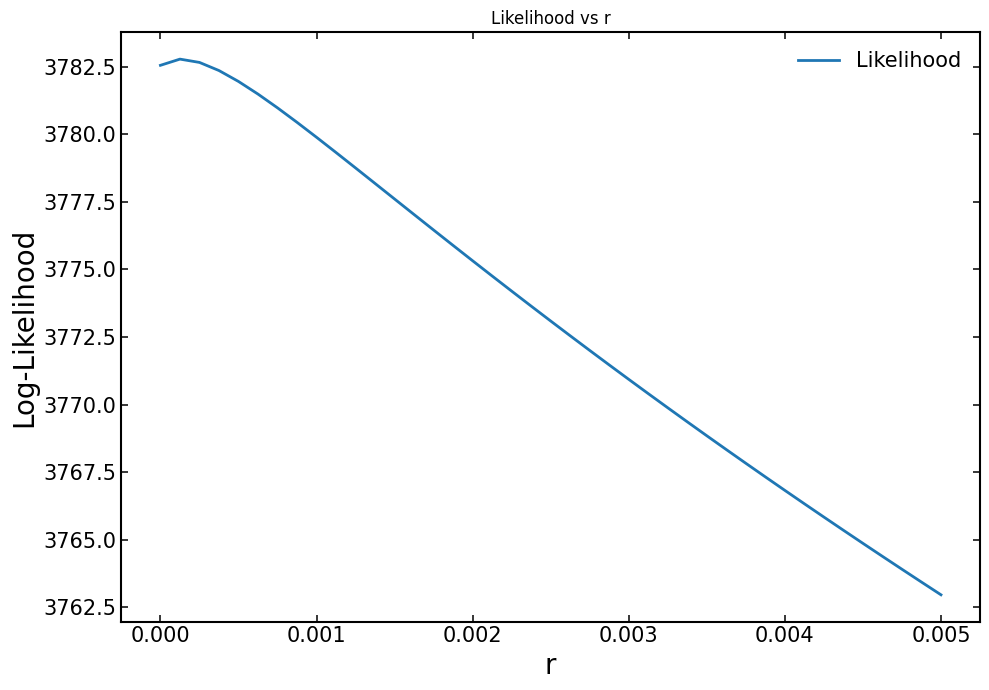

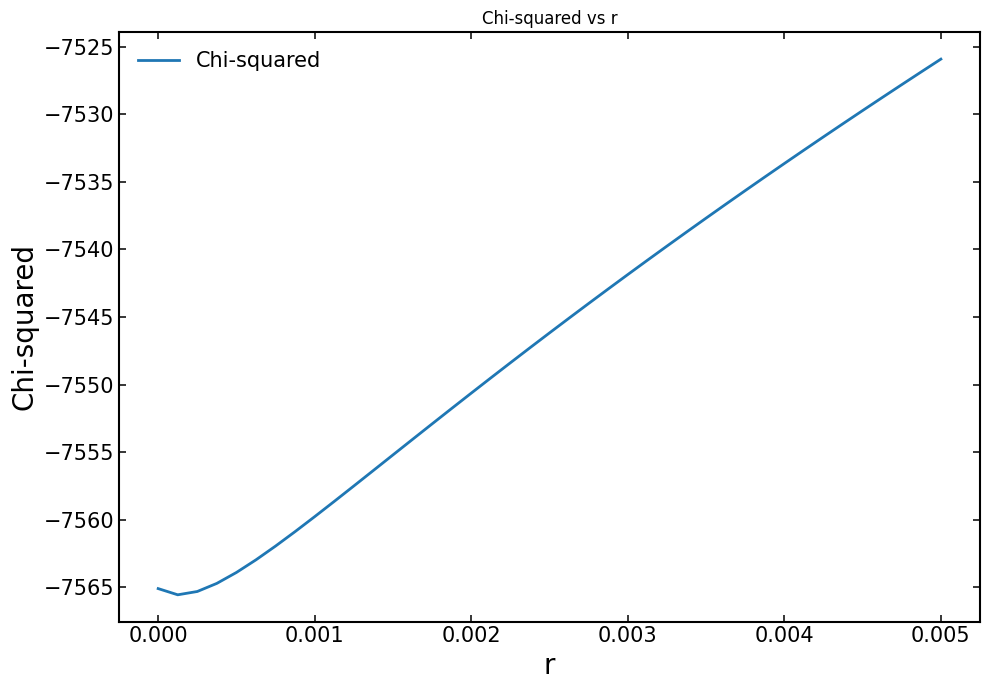

In [15]:
plt.plot(likelihood.parameter_ranges["r"], like_values[:, 0], label="Likelihood")
plt.xlabel("r")
plt.ylabel("Log-Likelihood")
plt.title("Likelihood vs r")
plt.legend()
plt.show()

plt.plot(likelihood.parameter_ranges["r"], chi2_values[:, 0], label="Chi-squared")
plt.xlabel("r")
plt.ylabel("Chi-squared")
plt.title("Chi-squared vs r")
plt.legend()
plt.show()

In [16]:
# Equivalent to running the full likelihood in one step
print("=== Running full likelihood ===")
full_like = PICSLike(param_file)

full_like.run()

=== Running full likelihood ===
2026-05-15 15:22:05 | picslike     | INFO     | PICSLike initialized!


2026-05-15 15:22:05 | picslike     | INFO     | Starting PICSLike analysis pipeline


2026-05-15 15:23:41 | picslike     | INFO     | Likelihood computation completed for 1 simulations


In [17]:
# Run PICSLike in the harmonic computation basis (SMW formulation, no
# truncation), so this is a *basis* comparison, not a compression comparison —
# the harmonic-basis log-likelihood should agree with the full pixel-space
# path to numerical precision (per ADR-0002 vocabulary; "compression" is
# reserved for truncated bases like pixel-direct with mode_fraction < 1).
#
# The library kwarg is still named `compression=` (residual ADR debt); the
# value is forwarded into `setup_computation_basis`.
basis_config = {
    "method": "harmonic",
}

basis_like = PICSLike(param_file, compression=basis_config)
basis_like.run()

2026-05-15 15:23:41 | picslike     | INFO     | PICSLike initialized!


2026-05-15 15:23:42 | picslike     | INFO     | Starting PICSLike analysis pipeline


2026-05-15 15:23:49 | basis        | DEBUG    | Basis setup: V=0.04s, eff_noise=0.01s, SMW=1.27s


2026-05-15 15:24:23 | picslike     | INFO     | Likelihood computation completed for 1 simulations


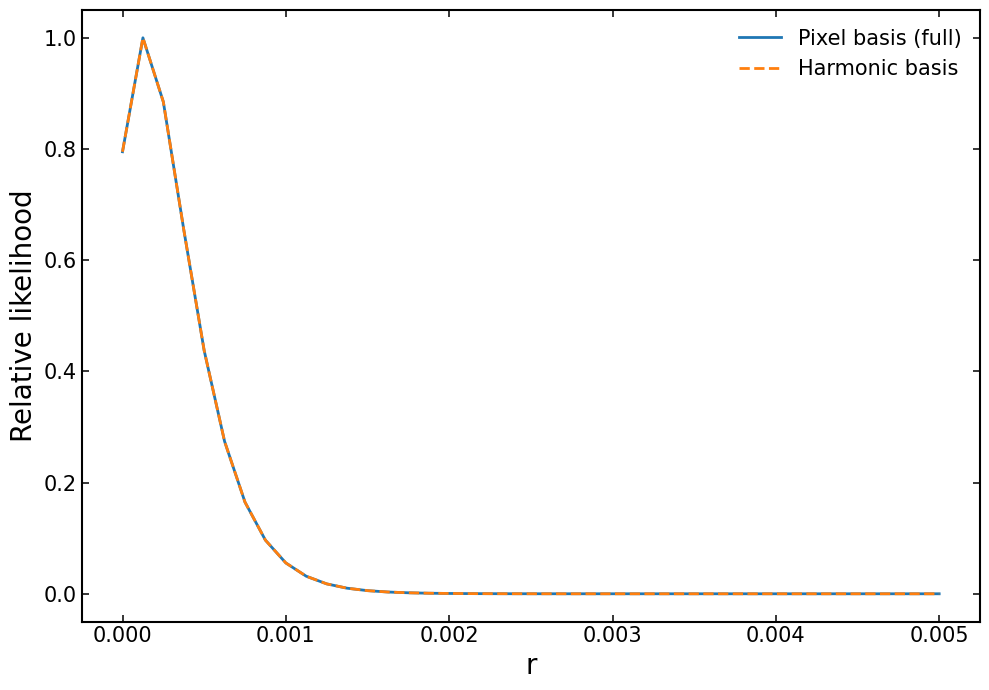

In [18]:
# Compare the Gaussian log-likelihood (chi² + logdet) between the pixel-space
# path and the harmonic-basis path. They should agree to numerical precision
# since the harmonic basis is exact (no truncation). Using get_chi_squared()
# alone would drop the logdet term, which is parameter-dependent and shifts
# the peak.
pixel_negloglike = -2 * full_like.get_log_likelihood()
harmonic_negloglike = -2 * basis_like.get_log_likelihood()

plt.plot(
    full_like.parameter_ranges["r"],
    np.exp(-0.5 * (pixel_negloglike - pixel_negloglike.min())),
    label="Pixel basis (full)",
)
plt.plot(
    full_like.parameter_ranges["r"],
    np.exp(-0.5 * (harmonic_negloglike - harmonic_negloglike.min())),
    "--",
    label="Harmonic basis",
)
plt.xlabel("r")
plt.ylabel("Relative likelihood")
plt.legend()
plt.show()